In [25]:
import pandas as pd
import numpy as np
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

sns.set(style="whitegrid", context="talk")
shap.initjs()

print("SHAP version:", shap.__version__)


SHAP version: 0.50.0


## XGBoost

In [26]:
import pandas as pd
import numpy as np

# Same processed dataset as in all modeling notebooks
features = pd.read_parquet("../../data/processed/market_all_features_with_sentiment.parquet")

print("Raw shape:", features.shape)
features.head()


Raw shape: (52424, 34)


,date,open,high,low,close,volume,adj close,ticker,sector,cap,...,sent_pos,sent_neg,sent_neu,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3,row_id,is_train,set
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,...,0.0,0.0,0.0,neutral,0.0,None,0.000000,ABB|2018-01-04,True,train
1,2018-01-04,7.882366,7.882366,7.882366,7.882366,0.0,7.882366,ALPINE,Consumer Discretionary,Large Cap,...,0.0,0.0,0.0,neutral,0.0,None,0.000000,ALPINE|2018-01-04,True,train
2,2018-01-04,332.666046,333.091339,317.440460,323.224487,111998.0,323.224487,ARYZTA,Consumer Staples,Mid Cap,...,1.0,0.0,0.0,positive,0.0,None,0.999941,ARYZTA|2018-01-04,True,train
3,2018-01-04,107.037628,107.741360,106.545007,107.670982,111416.0,107.670982,BALOISE,Insurance,Mid Cap,...,0.0,0.0,0.0,neutral,0.0,None,0.000000,BALOISE|2018-01-04,True,train
4,2018-01-04,47.071196,47.562372,47.071196,47.480511,19374.0,47.480511,BKW ENERGIE,Real Estate - Energy - Industrials,Small Cap,...,0.0,0.0,1.0,neutral,0.0,None,0.995683,BKW ENERGIE|2018-01-04,True,train


In [27]:
# How many news per ticker?
news_counts = (
    features.groupby("ticker")["sent_count"]
            .sum()
            .sort_values(ascending=False)
)

THRESHOLD = 1800
eligible_tickers = news_counts[news_counts >= THRESHOLD].index.tolist()
print("Eligible tickers:", eligible_tickers)

features = features[features["ticker"].isin(eligible_tickers)].copy()
print("After filtering:", features.shape)


Eligible tickers: ['UBS', 'SWISSCOM', 'NESTLE', 'VONTOBEL', 'BKW ENERGIE', 'ABB', 'JULIUS BAER', 'HELVETIA', 'LONZA', 'SWATCH', 'SWISS LIFE']
After filtering: (19338, 34)


In [28]:
# Forward-fill sentiment columns per ticker (limit=1) 
sent_cols = [
    "sent_mean", "sent_std", "sent_count",
    "sent_pos", "sent_neg", "sent_neu",
    "sent_lag1", "sent_roll3"
]

for col in sent_cols:
    features[col] = (
        features
        .groupby("ticker")[col]
        .transform(lambda x: x.ffill(limit=1))
    )

# Clean sentiment lag category
features["sent_cat_lag1"] = features["sent_cat_lag1"].replace("None", np.nan)
features["sent_cat_lag1"] = features["sent_cat_lag1"].fillna("neutral")
features["sent_lag1"]    = features["sent_lag1"].fillna(0.0)
features["sent_roll3"]   = features["sent_roll3"].fillna(0.0)

features[["sent_daily_cat", "sent_lag1", "sent_cat_lag1", "sent_roll3"]].head()


,sent_daily_cat,sent_lag1,sent_cat_lag1,sent_roll3
0,neutral,0.0,neutral,0.000000
4,neutral,0.0,neutral,0.995683
8,neutral,0.0,neutral,0.000000
10,neutral,0.0,neutral,0.000000
13,neutral,0.0,neutral,0.000000


In [29]:
features["date"] = pd.to_datetime(features["date"], errors="coerce")
features = features.sort_values(["ticker", "date"]).reset_index(drop=True)

features_model = features.copy()

# Target: t+1 next-day return
features_model["target_ret_next"] = (
    features_model.groupby("ticker")["return"].shift(-1)
)

# AR(5) lags
for lag in range(1, 6):
    features_model[f"ret_lag{lag}"] = (
        features_model.groupby("ticker")["return"].shift(lag)
    )

# Lagged vol
features_model["vol21_lag1"] = (
    features_model.groupby("ticker")["vol21"].shift(1)
)

print("features_model shape:", features_model.shape)
features_model.head()


features_model shape: (19338, 41)


,date,open,high,low,close,volume,adj close,ticker,sector,cap,...,row_id,is_train,set,target_ret_next,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21_lag1
0,2018-01-04,19.838642,19.958017,19.749111,19.935635,5738092.0,19.935635,ABB,Real Estate - Energy - Industrials,Mid Cap,...,ABB|2018-01-04,True,train,0.007485,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-01-05,19.920712,20.084852,19.883406,20.084852,4435594.0,20.084852,ABB,Real Estate - Energy - Industrials,Mid Cap,...,ABB|2018-01-05,True,train,0.000372,0.010972,NaN,NaN,NaN,NaN,NaN
2,2018-01-08,20.099777,20.137081,19.920715,20.092316,5029780.0,20.092316,ABB,Real Estate - Energy - Industrials,Mid Cap,...,ABB|2018-01-08,True,train,0.005199,0.007485,0.010972,NaN,NaN,NaN,NaN
3,2018-01-09,19.972940,20.196768,19.935636,20.196768,6974533.0,20.196768,ABB,Real Estate - Energy - Industrials,Mid Cap,...,ABB|2018-01-09,True,train,-0.007019,0.000372,0.007485,0.010972,NaN,NaN,NaN
4,2018-01-10,20.144539,20.159461,19.995321,20.055008,4184285.0,20.055008,ABB,Real Estate - Energy - Industrials,Mid Cap,...,ABB|2018-01-10,True,train,0.001116,0.005199,0.000372,0.007485,0.010972,NaN,NaN


### Build X_test_base and X_test_mm for SHAP

In [30]:
# Use existing split
train_df = features_model[features_model["set"] == "train"].copy()
test_df  = features_model[features_model["set"] == "test"].copy()

print("Raw shapes:")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

required_cols = ["target_ret_next"] + [f"ret_lag{i}" for i in range(1, 6)]
train_df = train_df.dropna(subset=required_cols).copy()
test_df  = test_df.dropna(subset=required_cols).copy()

print("\nAfter dropping rows with missing target / AR lags:")
print("train_df:", train_df.shape)
print("test_df :", test_df.shape)


Raw shapes:
train_df: (13827, 41)
test_df : (5511, 41)

After dropping rows with missing target / AR lags:
train_df: (13772, 41)
test_df : (5500, 41)


In [31]:
# === Baseline feature set (same as training XGBoost) ===
baseline_features = [
    "ret_lag1", "ret_lag2", "ret_lag3", "ret_lag4", "ret_lag5",
    "vol21", "vol63", "vol21_lag1",
    "ret_ema21", "ret_ema63",
    "px_ma21", "px_ma63", "px_ma200",
    "trend200_up",
]

print("Number of baseline features:", len(baseline_features))

# === Prepare dataframe for baseline SHAP ===
X_test_base = test_df[baseline_features].copy()
print("X_test_base shape:", X_test_base.shape)
X_test_base.head()


Number of baseline features: 14
X_test_base shape: (5500, 14)


,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol63,vol21_lag1,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up
1257,-0.014055,0.008147,-0.009821,0.012070,0.008593,0.012622,0.013918,0.012321,-0.001641,-0.000002,26.820713,26.262059,25.495877,1
1258,0.024234,-0.014055,0.008147,-0.009821,0.012070,0.013776,0.012018,0.012622,0.000711,0.000756,26.785139,26.304895,25.487104,1
1259,0.033751,0.024234,-0.014055,0.008147,-0.009821,0.015740,0.012552,0.013776,0.003715,0.001787,26.788696,26.366556,25.482730,1
1260,0.000673,0.033751,0.024234,-0.014055,0.008147,0.015704,0.012543,0.015740,0.003438,0.001752,26.798923,26.429107,25.478581,1
1261,0.009418,0.000673,0.033751,0.024234,-0.014055,0.015621,0.012212,0.015704,0.003982,0.001992,26.834942,26.503663,25.476000,1


### Compute sent_cat_lag1_num and build multimodal test set for SHAP

In [35]:
# === Numeric mapping for categorical sentiment lag ===
sent_map = {"negative": -1, "neutral": 0, "positive": 1}

# Make sure the column exists and map to numeric
test_df["sent_cat_lag1_num"] = test_df["sent_cat_lag1"].map(sent_map)

# === Multimodal feature set (must match XGBoost training) ===
multimodal_features = baseline_features + [
    "sent_lag1",
    "sent_cat_lag1_num",
    "sent_roll3",
]

print("Number of multimodal features:", len(multimodal_features))

# Build test design matrix for multimodal XGBoost
X_test_mm = test_df[multimodal_features].copy()
print("X_test_mm shape:", X_test_mm.shape)

# Quick NaN check
print("\nNaNs per column (top 10):")
print(X_test_mm.isna().sum().sort_values(ascending=False).head(10))

X_test_mm.head()



Number of multimodal features: 17
X_test_mm shape: (5500, 17)

NaNs per column (top 10):
ret_lag1      0
ret_lag2      0
ret_lag3      0
ret_lag4      0
ret_lag5      0
vol21         0
vol63         0
vol21_lag1    0
ret_ema21     0
ret_ema63     0
dtype: int64


,ret_lag1,ret_lag2,ret_lag3,ret_lag4,ret_lag5,vol21,vol63,vol21_lag1,ret_ema21,ret_ema63,px_ma21,px_ma63,px_ma200,trend200_up,sent_lag1,sent_cat_lag1_num,sent_roll3
1257,-0.014055,0.008147,-0.009821,0.012070,0.008593,0.012622,0.013918,0.012321,-0.001641,-0.000002,26.820713,26.262059,25.495877,1,0.000000,0,0.000000
1258,0.024234,-0.014055,0.008147,-0.009821,0.012070,0.013776,0.012018,0.012622,0.000711,0.000756,26.785139,26.304895,25.487104,1,0.989315,1,0.994940
1259,0.033751,0.024234,-0.014055,0.008147,-0.009821,0.015740,0.012552,0.013776,0.003715,0.001787,26.788696,26.366556,25.482730,1,0.429806,1,0.804879
1260,0.000673,0.033751,0.024234,-0.014055,0.008147,0.015704,0.012543,0.015740,0.003438,0.001752,26.798923,26.429107,25.478581,1,0.000000,0,0.000000
1261,0.009418,0.000673,0.033751,0.024234,-0.014055,0.015621,0.012212,0.015704,0.003982,0.001992,26.834942,26.503663,25.476000,1,0.994127,1,0.804416


### Load saved XGBoost models

In [33]:
import xgboost as xgb
import shap

print("SHAP version:", shap.__version__)

MODEL_DIR = "../models/xgboost"

# --- Load XGBoost baseline model (raw features) ---
xgb_base = xgb.XGBRegressor()
xgb_base.load_model(f"{MODEL_DIR}/xgb_base_market_only.json")

# --- Load XGBoost multimodal model (raw features) ---
xgb_mm = xgb.XGBRegressor()
xgb_mm.load_model(f"{MODEL_DIR}/xgb_mm_multimodal.json")

print("Models loaded from JSON.")

# --- X_test_base and X_test_mm are ALREADY the raw features we need ---
print("X_test_base shape:", X_test_base.shape)
print("X_test_mm shape  :", X_test_mm.shape)

# Ensure no missing values
print("NaNs baseline:", X_test_base.isna().sum().sum())
print("NaNs multimodal:", X_test_mm.isna().sum().sum())

# y_test stored for later
y_test = test_df["target_ret_next"].values
print("y_test shape:", y_test.shape)



SHAP version: 0.50.0
Models loaded from JSON.
X_test_base shape: (5500, 14)
X_test_mm shape  : (5500, 17)
NaNs baseline: 0
NaNs multimodal: 0
y_test shape: (5500,)


In [37]:
# --- Ensure categorical sentiment is correctly mapped ---
sent_map = {"negative": -1, "neutral": 0, "positive": 1}

if "sent_cat_lag1_num" not in train_df.columns:
    train_df["sent_cat_lag1_num"] = train_df["sent_cat_lag1"].map(sent_map)

if "sent_cat_lag1_num" not in test_df.columns:
    test_df["sent_cat_lag1_num"] = test_df["sent_cat_lag1"].map(sent_map)

# Sanity check
print("sent_cat_lag1_num in train?", "sent_cat_lag1_num" in train_df.columns)
print("sent_cat_lag1_num in test ?", "sent_cat_lag1_num" in test_df.columns)


sent_cat_lag1_num in train? True
sent_cat_lag1_num in test ? True


### Build background data & compute SHAP values

In [38]:
import shap
import numpy as np

print("SHAP version:", shap.__version__)

# --- 1) Rebuild train feature matrices (for background sample) ---
X_train_base = train_df[baseline_features].copy()
X_train_mm   = train_df[multimodal_features].copy()

print("X_train_base shape:", X_train_base.shape)
print("X_train_mm shape  :", X_train_mm.shape)

# --- 2) Background sample (used by TreeExplainer for expectations) ---
#    Use up to 1000 rows for speed. If you have <1000, it just uses all.
background_base = shap.sample(X_train_base, 1000, random_state=42)
background_mm   = shap.sample(X_train_mm,   1000, random_state=42)

print("Background shapes:")
print("background_base:", background_base.shape)
print("background_mm  :", background_mm.shape)

# --- 3) Build TreeExplainers for both models ---
explainer_base = shap.TreeExplainer(
    xgb_base,
    data=background_base,
    feature_perturbation="interventional",
)

explainer_mm = shap.TreeExplainer(
    xgb_mm,
    data=background_mm,
    feature_perturbation="interventional",
)

print("TreeExplainers created.")

# --- 4) Optional: sample test set for SHAP (for faster plotting) ---
X_test_base_sample = shap.sample(X_test_base, 1000, random_state=42)
X_test_mm_sample   = shap.sample(X_test_mm,   1000, random_state=42)

print("Sampled test shapes:")
print("X_test_base_sample:", X_test_base_sample.shape)
print("X_test_mm_sample  :", X_test_mm_sample.shape)

# --- 5) Compute SHAP values ---
shap_values_base = explainer_base.shap_values(X_test_base_sample)
shap_values_mm   = explainer_mm.shap_values(X_test_mm_sample)

print("SHAP values computed.")
print("shap_values_base shape:", np.array(shap_values_base).shape)
print("shap_values_mm shape  :", np.array(shap_values_mm).shape)


SHAP version: 0.50.0
X_train_base shape: (13772, 14)
X_train_mm shape  : (13772, 17)
Background shapes:
background_base: (1000, 14)
background_mm  : (1000, 17)
TreeExplainers created.
Sampled test shapes:
X_test_base_sample: (1000, 14)
X_test_mm_sample  : (1000, 17)


100%|===================| 995/1000 [00:20<00:00]        

SHAP values computed.
shap_values_base shape: (1000, 14)
shap_values_mm shape  : (1000, 17)


In [61]:
# CHUNK 7: aggregate mean |SHAP| and save CSVs
from pathlib import Path
# Fix variable names: use shap_values_base and shap_values_mm, which are computed above
imp_base = np.abs(shap_values_base).mean(axis=0)
imp_mm   = np.abs(shap_values_mm).mean(axis=0)

shap_base_df = pd.DataFrame({
    "feature": baseline_features,
    "shap_mean_abs": imp_base
}).sort_values("shap_mean_abs", ascending=False)

shap_mm_df = pd.DataFrame({
    "feature": multimodal_features,
    "shap_mean_abs": imp_mm
}).sort_values("shap_mean_abs", ascending=False)

display(shap_base_df.head(15))
display(shap_mm_df.head(15))

from pathlib import Path

# Ensure the results directory exists
XGB_RESULTS_DIR = Path("../results/xgboost")
XGB_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

shap_base_path = XGB_RESULTS_DIR / "shap_importance_base_overall.csv"
shap_mm_path   = XGB_RESULTS_DIR / "shap_importance_mm_overall.csv"

shap_base_df.to_csv(shap_base_path, index=False)
shap_mm_df.to_csv(shap_mm_path, index=False)

print("Saved:")
print(" -", shap_base_path)
print(" -", shap_mm_path)


,feature,shap_mean_abs
12,px_ma200,0.001414
6,vol63,0.000985
11,px_ma63,0.000915
7,vol21_lag1,0.000860
2,ret_lag3,0.000802
10,px_ma21,0.000793
8,ret_ema21,0.000749
9,ret_ema63,0.000716
1,ret_lag2,0.000701
0,ret_lag1,0.000641


,feature,shap_mean_abs
12,px_ma200,0.001316
6,vol63,0.001109
10,px_ma21,0.000963
11,px_ma63,0.000864
7,vol21_lag1,0.000773
8,ret_ema21,0.000734
2,ret_lag3,0.000731
16,sent_roll3,0.000688
9,ret_ema63,0.000682
1,ret_lag2,0.000677


Saved:
 - ..\results\xgboost\shap_importance_base_overall.csv
 - ..\results\xgboost\shap_importance_mm_overall.csv


In [62]:
# CHUNK 8: comparison (baseline vs multimodal)

# Align on union of features (baseline has no sentiment cols -> 0)
all_features = multimodal_features

base_aligned = pd.Series(0.0, index=all_features, name="shap_base")
base_aligned.loc[shap_base_df["feature"]] = shap_base_df.set_index("feature")["shap_mean_abs"]

mm_aligned = pd.Series(0.0, index=all_features, name="shap_mm")
mm_aligned.loc[shap_mm_df["feature"]] = shap_mm_df.set_index("feature")["shap_mean_abs"]

shap_compare = pd.DataFrame({
    "feature": all_features,
    "shap_base": base_aligned.values,
    "shap_mm":   mm_aligned.values,
})
shap_compare["delta"] = shap_compare["shap_mm"] - shap_compare["shap_base"]

shap_compare_sorted = shap_compare.sort_values("shap_mm", ascending=False)
display(shap_compare_sorted.head(20))

cmp_path = XGB_RESULTS_DIR / "shap_importance_xgb_compare.csv"
shap_compare_sorted.to_csv(cmp_path, index=False)
print("Saved:", cmp_path)


,feature,shap_base,shap_mm,delta
12,px_ma200,0.001414,0.001316,-0.000098
6,vol63,0.000985,0.001109,0.000124
10,px_ma21,0.000793,0.000963,0.000171
11,px_ma63,0.000915,0.000864,-0.000051
7,vol21_lag1,0.000860,0.000773,-0.000087
8,ret_ema21,0.000749,0.000734,-0.000015
2,ret_lag3,0.000802,0.000731,-0.000071
16,sent_roll3,0.000000,0.000688,0.000688
9,ret_ema63,0.000716,0.000682,-0.000035
1,ret_lag2,0.000701,0.000677,-0.000024


Saved: ..\results\xgboost\shap_importance_xgb_compare.csv


### Global SHAP summary plots

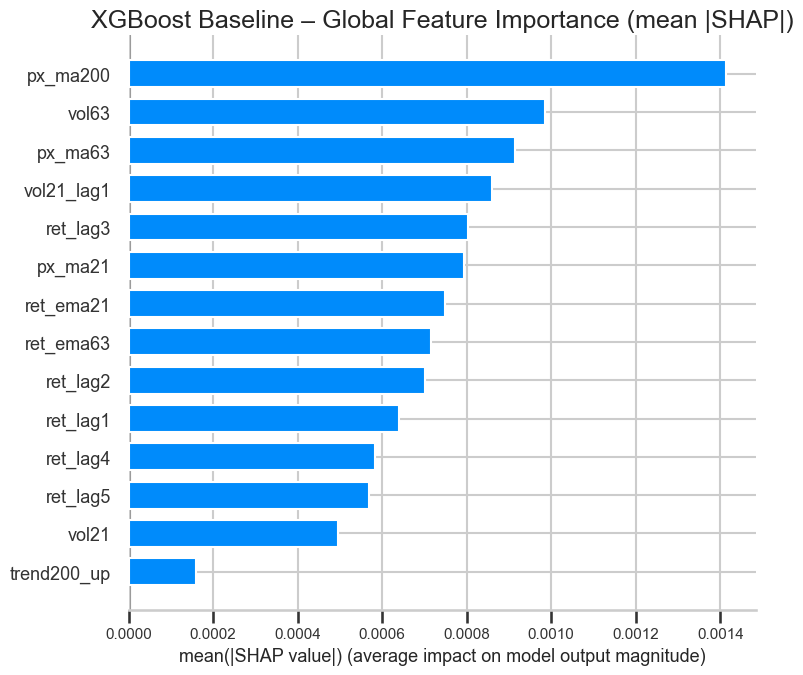

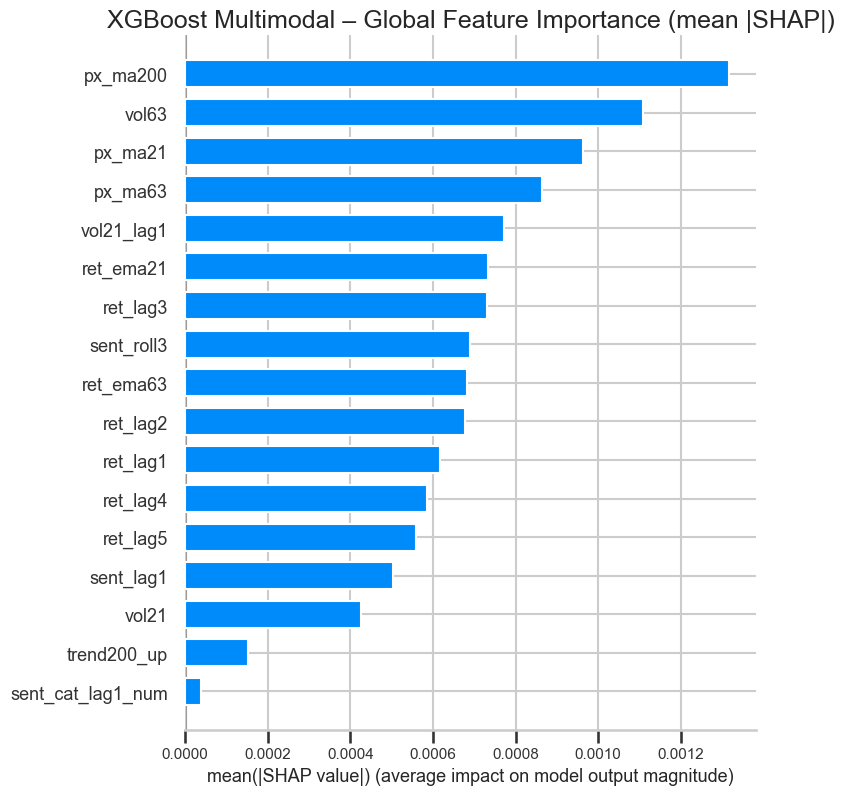

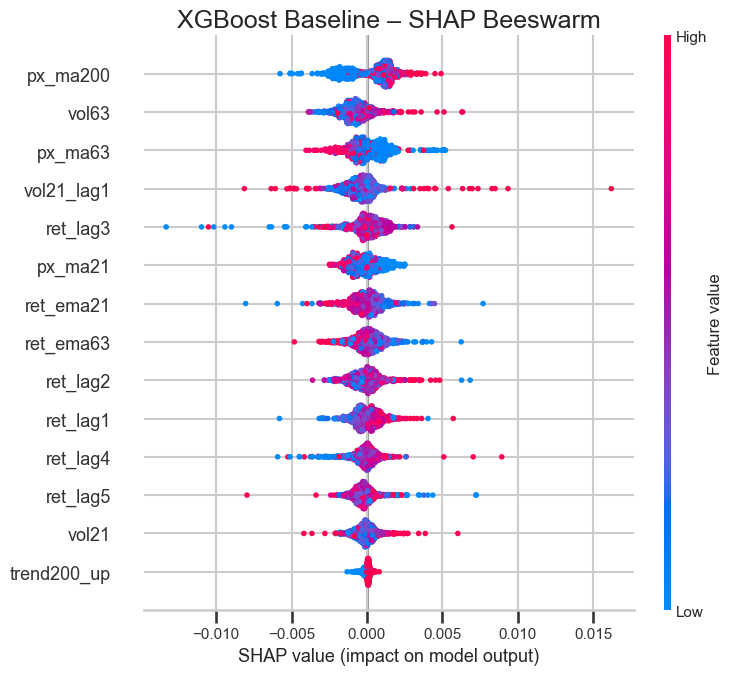

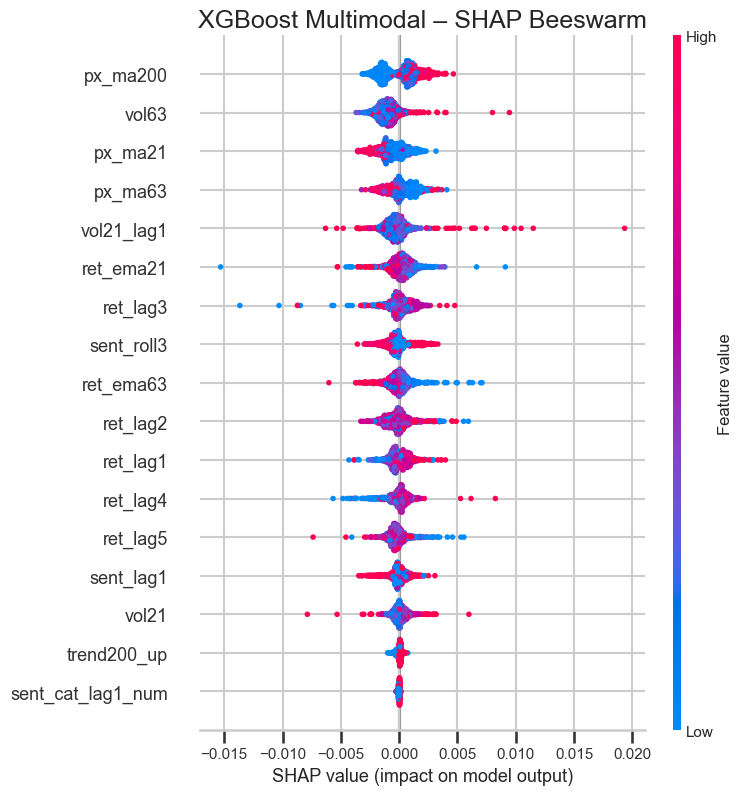

In [39]:
import matplotlib.pyplot as plt

# --- 6.1 Bar plots: mean |SHAP| importance ---

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_base,
    X_test_base_sample,
    plot_type="bar",
    show=False
)
plt.title("XGBoost Baseline – Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_mm,
    X_test_mm_sample,
    plot_type="bar",
    show=False
)
plt.title("XGBoost Multimodal – Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

# --- 6.2 Beeswarm plots: distribution of effects ---

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_base,
    X_test_base_sample,
    show=False
)
plt.title("XGBoost Baseline – SHAP Beeswarm")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_mm,
    X_test_mm_sample,
    show=False
)
plt.title("XGBoost Multimodal – SHAP Beeswarm")
plt.tight_layout()
plt.show()


In [63]:
import os
import matplotlib.pyplot as plt

# --- Create directory ---
save_dir = "../results/xgboost/shap"
os.makedirs(save_dir, exist_ok=True)

# --- 1) Baseline bar plot ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_base,
    X_test_base_sample,
    plot_type="bar",
    show=False
)
plt.title("XGBoost Baseline – Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(f"{save_dir}/shap_bar_baseline.png", dpi=300)
plt.close()

# --- 2) Multimodal bar plot ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_mm,
    X_test_mm_sample,
    plot_type="bar",
    show=False
)
plt.title("XGBoost Multimodal – Global Feature Importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(f"{save_dir}/shap_bar_multimodal.png", dpi=300)
plt.close()

# --- 3) Baseline beeswarm ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_base,
    X_test_base_sample,
    show=False
)
plt.title("XGBoost Baseline – SHAP Beeswarm")
plt.tight_layout()
plt.savefig(f"{save_dir}/shap_beeswarm_baseline.png", dpi=300)
plt.close()

# --- 4) Multimodal beeswarm ---
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_mm,
    X_test_mm_sample,
    show=False
)
plt.title("XGBoost Multimodal – SHAP Beeswarm")
plt.tight_layout()
plt.savefig(f"{save_dir}/shap_beeswarm_multimodal.png", dpi=300)
plt.close()

print("All SHAP figures saved to:", save_dir)


C:\Users\mkcak\AppData\Local\Temp\ipykernel_3936\1160449281.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\mkcak\AppData\Local\Temp\ipykernel_3936\1160449281.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\mkcak\AppData\Local\Temp\ipykernel_3936\1160449281.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
C:\Users\mkcak\AppData\Local\Temp\ipykernel_3936\1160449281.py:4

All SHAP figures saved to: ../results/xgboost/shap


## LSTM

### Load saved LSTM models & test sequences

In [41]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# Base dirs (should match your other sections)
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")

LSTM_MODELS_DIR = MODELS_DIR / "lstm"
LSTM_RESULTS_DIR = RESULTS_DIR / "lstm"

print("LSTM_MODELS_DIR :", LSTM_MODELS_DIR)
print("LSTM_RESULTS_DIR:", LSTM_RESULTS_DIR)

# === Load LSTM models ===
lstm_base = load_model(LSTM_MODELS_DIR / "lstm_base_market_only.keras")
lstm_mm   = load_model(LSTM_MODELS_DIR / "lstm_mm_multimodal.keras")

print("Loaded LSTM models:")
print(" - lstm_base_market_only.keras")
print(" - lstm_mm_multimodal.keras")

# === Load saved test sequences ===
base_npz = np.load(LSTM_RESULTS_DIR / "test_sequences_lstm_base.npz")
mm_npz   = np.load(LSTM_RESULTS_DIR / "test_sequences_lstm_mm.npz")

X_test_base_seq = base_npz["X_test"]
y_test_base_seq = base_npz["y_test"]
feature_names_base = base_npz["feature_names"].astype(str)

X_test_mm_seq = mm_npz["X_test"]
y_test_mm_seq = mm_npz["y_test"]
feature_names_mm = mm_npz["feature_names"].astype(str)

print("\nBaseline LSTM test sequences:")
print("  X_test_base_seq shape:", X_test_base_seq.shape)
print("  y_test_base_seq shape:", y_test_base_seq.shape)
print("  #features (base):    ", len(feature_names_base))
print("  features (base):     ", list(feature_names_base))

print("\nMultimodal LSTM test sequences:")
print("  X_test_mm_seq shape:", X_test_mm_seq.shape)
print("  y_test_mm_seq shape:", y_test_mm_seq.shape)
print("  #features (mm):     ", len(feature_names_mm))
print("  features (mm):      ", list(feature_names_mm))


c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\mkcak\anaconda3\envs\financetech\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update

LSTM_MODELS_DIR : ..\models\lstm
LSTM_RESULTS_DIR: ..\results\lstm
Loaded LSTM models:
 - lstm_base_market_only.keras
 - lstm_mm_multimodal.keras

Baseline LSTM test sequences:
  X_test_base_seq shape: (5170, 30, 14)
  y_test_base_seq shape: (5170,)
  #features (base):     14
  features (base):      [np.str_('ret_lag1'), np.str_('ret_lag2'), np.str_('ret_lag3'), np.str_('ret_lag4'), np.str_('ret_lag5'), np.str_('vol21'), np.str_('vol63'), np.str_('vol21_lag1'), np.str_('ret_ema21'), np.str_('ret_ema63'), np.str_('px_ma21'), np.str_('px_ma63'), np.str_('px_ma200'), np.str_('trend200_up')]

Multimodal LSTM test sequences:
  X_test_mm_seq shape: (5170, 30, 17)
  y_test_mm_seq shape: (5170,)
  #features (mm):      17
  features (mm):       [np.str_('ret_lag1'), np.str_('ret_lag2'), np.str_('ret_lag3'), np.str_('ret_lag4'), np.str_('ret_lag5'), np.str_('vol21'), np.str_('vol63'), np.str_('vol21_lag1'), np.str_('ret_ema21'), np.str_('ret_ema63'), np.str_('px_ma21'), np.str_('px_ma63'), np.st

### Define occlusion-based importance function

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Just in case we need it later
def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def occlusion_importance_lstm(
    model,
    X_test_seq,
    y_test,
    feature_names,
    max_samples=2000,
    random_state=42,
):
    """
    Simple occlusion-based importance for LSTM:
    - Compute baseline RMSE on a subset of test sequences.
    - For each feature:
        -> set that feature to 0 (since inputs are standardized)
        -> recompute RMSE
        -> importance = RMSE_perturbed - RMSE_base  (ΔRMSE)
    Larger positive ΔRMSE => more important feature.
    """
    np.random.seed(random_state)

    n_samples = X_test_seq.shape[0]
    if max_samples is not None and n_samples > max_samples:
        idx = np.random.choice(n_samples, size=max_samples, replace=False)
        X_eval = X_test_seq[idx].copy()
        y_eval = y_test[idx].copy()
    else:
        X_eval = X_test_seq.copy()
        y_eval = y_test.copy()

    # Baseline performance
    y_pred_base = model.predict(X_eval, verbose=0).ravel()
    rmse_base = np.sqrt(mean_squared_error(y_eval, y_pred_base))

    print(f"Baseline RMSE on evaluation subset (n={len(y_eval)}): {rmse_base:.6f}")

    n_features = X_eval.shape[2]
    assert n_features == len(feature_names), "Feature count mismatch!"

    deltas = []
    for j in range(n_features):
        X_perturbed = X_eval.copy()
        # occlude feature j across all timesteps by setting to 0 (standardized space)
        X_perturbed[:, :, j] = 0.0

        y_pred_pert = model.predict(X_perturbed, verbose=0).ravel()
        rmse_pert = np.sqrt(mean_squared_error(y_eval, y_pred_pert))
        delta_rmse = rmse_pert - rmse_base

        deltas.append(delta_rmse)
        print(f"{feature_names[j]:20s} -> ΔRMSE = {delta_rmse:.6f}")

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "delta_rmse": deltas,
        })
        .sort_values("delta_rmse", ascending=False)
        .reset_index(drop=True)
    )

    return importance_df


### Compute occlusion importance for LSTM Baseline & LSTM + Sentiment

In [44]:
# === LSTM BASELINE (market-only) ===

feat_names_base_lstm = baseline_features

importance_lstm_base = occlusion_importance_lstm(
    model=lstm_base,
    X_test_seq=X_test_base_seq,
    y_test=y_test_base_seq,
    feature_names=feat_names_base_lstm,
    max_samples=2000,
    random_state=42,
)

print("\nOcclusion-based importance — LSTM Baseline (market-only)")
display(importance_lstm_base)


# === LSTM MULTIMODAL (market + sentiment) ===

feat_names_mm_lstm = multimodal_features

importance_lstm_mm = occlusion_importance_lstm(
    model=lstm_mm,
    X_test_seq=X_test_mm_seq,
    y_test=y_test_mm_seq,
    feature_names=feat_names_mm_lstm,
    max_samples=2000,
    random_state=42,
)

print("\nOcclusion-based importance — LSTM + Sentiment (multimodal)")
display(importance_lstm_mm)


Baseline RMSE on evaluation subset (n=2000): 0.014432
ret_lag1             -> ΔRMSE = 0.000008
ret_lag2             -> ΔRMSE = 0.000033
ret_lag3             -> ΔRMSE = 0.000116
ret_lag4             -> ΔRMSE = -0.000043
ret_lag5             -> ΔRMSE = 0.000054
vol21                -> ΔRMSE = -0.000079
vol63                -> ΔRMSE = 0.000016
vol21_lag1           -> ΔRMSE = 0.000036
ret_ema21            -> ΔRMSE = -0.000022
ret_ema63            -> ΔRMSE = -0.000042
px_ma21              -> ΔRMSE = 0.000235
px_ma63              -> ΔRMSE = -0.000003
px_ma200             -> ΔRMSE = 0.000230
trend200_up          -> ΔRMSE = -0.000021

Occlusion-based importance — LSTM Baseline (market-only)


,feature,delta_rmse
0,px_ma21,0.000235
1,px_ma200,0.000230
2,ret_lag3,0.000116
3,ret_lag5,0.000054
4,vol21_lag1,0.000036
5,ret_lag2,0.000033
6,vol63,0.000016
7,ret_lag1,0.000008
8,px_ma63,-0.000003
9,trend200_up,-0.000021


Baseline RMSE on evaluation subset (n=2000): 0.015767
ret_lag1             -> ΔRMSE = 0.000000
ret_lag2             -> ΔRMSE = -0.000000
ret_lag3             -> ΔRMSE = -0.000000
ret_lag4             -> ΔRMSE = 0.000000
ret_lag5             -> ΔRMSE = -0.000000
vol21                -> ΔRMSE = 0.000001
vol63                -> ΔRMSE = -0.000001
vol21_lag1           -> ΔRMSE = -0.000001
ret_ema21            -> ΔRMSE = 0.000000
ret_ema63            -> ΔRMSE = -0.000000
px_ma21              -> ΔRMSE = 0.034315
px_ma63              -> ΔRMSE = 0.124883
px_ma200             -> ΔRMSE = 0.000750
trend200_up          -> ΔRMSE = -0.000007
sent_lag1            -> ΔRMSE = -0.000014
sent_cat_lag1_num    -> ΔRMSE = 0.000037
sent_roll3           -> ΔRMSE = 0.000034

Occlusion-based importance — LSTM + Sentiment (multimodal)


,feature,delta_rmse
0,px_ma63,1.248827e-01
1,px_ma21,3.431543e-02
2,px_ma200,7.498586e-04
3,sent_cat_lag1_num,3.667597e-05
4,sent_roll3,3.438824e-05
5,vol21,6.381157e-07
6,ret_lag4,4.588280e-07
7,ret_lag1,1.717312e-07
8,ret_ema21,2.277191e-08
9,ret_lag2,-9.736909e-09


### Build comparison table for LSTM occlusion importances

In [55]:
# --- Make sure we have these from the previous cell ---
# importance_lstm_base  -> occlusion importance for baseline LSTM
# importance_lstm_mm    -> occlusion importance for multimodal LSTM

# 1) Normalize column names (in case the function used rmse_full / rmse_occluded)
def _normalize_imp(df, model_label):
    df = df.copy()
    
    # try to detect RMSE columns
    if "delta_rmse" not in df.columns:
        if {"rmse_full", "rmse_occluded"}.issubset(df.columns):
            df["delta_rmse"] = df["rmse_occluded"] - df["rmse_full"]
        elif {"rmse_base", "rmse_occluded"}.issubset(df.columns):
            df["delta_rmse"] = df["rmse_occluded"] - df["rmse_base"]
        # otherwise assume delta_rmse is already there or user will adjust
    
    return df[["feature", "delta_rmse"]].rename(
        columns={"delta_rmse": f"delta_rmse_{model_label}"}
    )

imp_base_norm = _normalize_imp(importance_lstm_base, "base")
imp_mm_norm   = _normalize_imp(importance_lstm_mm,   "mm")

# 2) Merge on feature name
lstm_imp_compare = imp_base_norm.merge(
    imp_mm_norm,
    on="feature",
    how="outer"
)

# 3) Extra column: how much more/less sensitive the multimodal model is
lstm_imp_compare["delta_diff_mm_minus_base"] = (
    lstm_imp_compare["delta_rmse_mm"] - lstm_imp_compare["delta_rmse_base"]
)

# 4) Sort by multimodal importance (largest RMSE worsening when occluded)
lstm_imp_compare = lstm_imp_compare.sort_values(
    "delta_rmse_mm",
    ascending=False
).reset_index(drop=True)

print("Occlusion-based feature importance comparison — LSTM (Baseline vs Multimodal)")
display(lstm_imp_compare)

from pathlib import Path

# Path to results/lstm
RESULTS_DIR = Path("../results")
LSTM_RESULTS_DIR = RESULTS_DIR / "lstm"
LSTM_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Save the already computed summary table
save_path = LSTM_RESULTS_DIR / "lstm_imp_compare.csv"
lstm_imp_compare.to_csv(save_path, index=False)

print("Saved LSTM interpretability summary to:", save_path)



Occlusion-based feature importance comparison — LSTM (Baseline vs Multimodal)


,feature,delta_rmse_base,delta_rmse_mm,delta_diff_mm_minus_base
0,px_ma63,-0.000003,1.248827e-01,0.124886
1,px_ma21,0.000235,3.431543e-02,0.034080
2,px_ma200,0.000230,7.498586e-04,0.000519
3,sent_cat_lag1_num,NaN,3.667597e-05,NaN
4,sent_roll3,NaN,3.438824e-05,NaN
5,vol21,-0.000079,6.381157e-07,0.000079
6,ret_lag4,-0.000043,4.588280e-07,0.000044
7,ret_lag1,0.000008,1.717312e-07,-0.000008
8,ret_ema21,-0.000022,2.277191e-08,0.000022
9,ret_lag2,0.000033,-9.736909e-09,-0.000034


Saved LSTM interpretability summary to: ..\results\lstm\lstm_imp_compare.csv


C:\Users\mkcak\AppData\Local\Temp\ipykernel_3936\3592133433.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


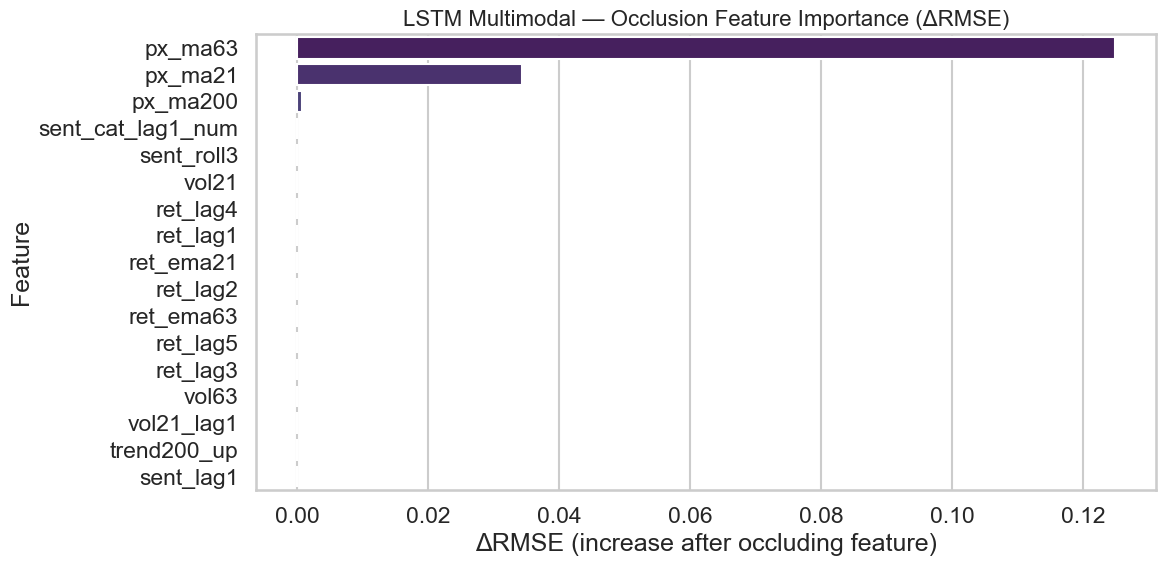

Saved figure: ..\results\lstm\lstm_mm_occlusion_barplot.png


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the comparison table created earlier
df_mm_plot = lstm_imp_compare.copy()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_mm_plot,
    x="delta_rmse_mm",
    y="feature",
    palette="viridis"
)

plt.title("LSTM Multimodal — Occlusion Feature Importance (ΔRMSE)", fontsize=16)
plt.xlabel("ΔRMSE (increase after occluding feature)")
plt.ylabel("Feature")
plt.tight_layout()

# Save
save_path = RESULTS_DIR / "lstm" / "lstm_mm_occlusion_barplot.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved figure:", save_path)


<Figure size 800x500 with 0 Axes>

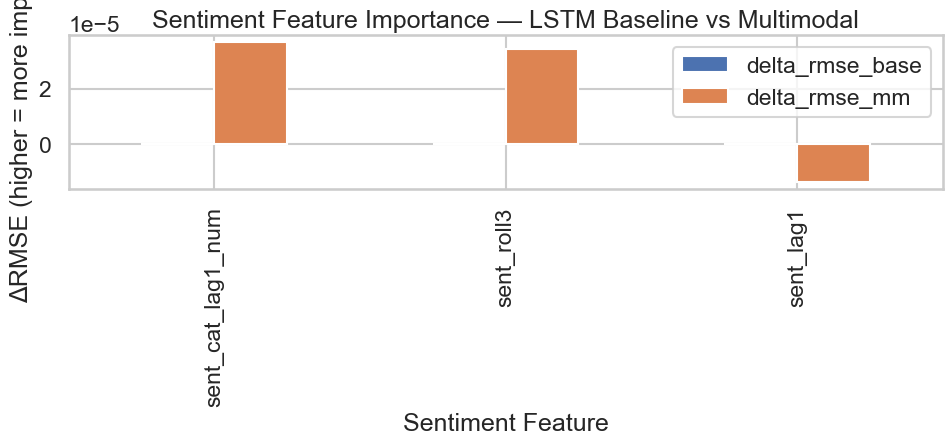

Saved figure: ..\results\lstm\lstm_sentiment_comparison.png


In [47]:
sentiment_features = [
    "sent_lag1",
    "sent_cat_lag1_num",
    "sent_roll3"
]

df_sent = lstm_imp_compare[lstm_imp_compare["feature"].isin(sentiment_features)].copy()

plt.figure(figsize=(8, 5))
df_sent.set_index("feature")[["delta_rmse_base", "delta_rmse_mm"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sentiment Feature Importance — LSTM Baseline vs Multimodal")
plt.xlabel("Sentiment Feature")
plt.ylabel("ΔRMSE (higher = more important)")
plt.tight_layout()

# Save
save_path = RESULTS_DIR / "lstm" / "lstm_sentiment_comparison.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("Saved figure:", save_path)


In [48]:
top10_mm = lstm_imp_compare.head(10)
print("Top-10 Most Important Features (LSTM Multimodal):")
display(top10_mm)

top10_path = RESULTS_DIR / "lstm" / "lstm_top10_features.csv"
top10_mm.to_csv(top10_path, index=False)
print("Saved:", top10_path)


Top-10 Most Important Features (LSTM Multimodal):


,feature,delta_rmse_base,delta_rmse_mm,delta_diff_mm_minus_base
0,px_ma63,-0.000003,1.248827e-01,0.124886
1,px_ma21,0.000235,3.431543e-02,0.034080
2,px_ma200,0.000230,7.498586e-04,0.000519
3,sent_cat_lag1_num,NaN,3.667597e-05,NaN
4,sent_roll3,NaN,3.438824e-05,NaN
5,vol21,-0.000079,6.381157e-07,0.000079
6,ret_lag4,-0.000043,4.588280e-07,0.000044
7,ret_lag1,0.000008,1.717312e-07,-0.000008
8,ret_ema21,-0.000022,2.277191e-08,0.000022
9,ret_lag2,0.000033,-9.736909e-09,-0.000034


Saved: ..\results\lstm\lstm_top10_features.csv
